### IMPORTO LAS LIBRERIAS 

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

### CARGO MI DATA SET

In [3]:
df = pd.read_csv("dataset_ampliado_psicofarmacos_ml.csv")

df.head()

,anio,provincia,grupo_etario,genero,consumo_psicofarmacos_pct,tasa_ansiedad_pct,desempleo_pct,consumo_alcohol_pct,consumo_tabaco_pct,acceso_salud_mental,impacto_postpandemia,fuente_base
0,2019,Buenos Aires,18-29,Mujer,11.58,37.0,12.8,47.5,23.3,Bajo,Bajo,SEDRONAR / ENCoPraC / COFA (dataset ampliado c...
1,2019,Buenos Aires,18-29,Varon,8.37,41.0,12.8,74.0,18.7,Alto,Bajo,SEDRONAR / ENCoPraC / COFA (dataset ampliado c...
2,2019,Buenos Aires,30-44,Mujer,12.99,20.5,7.4,54.6,35.8,Medio,Bajo,SEDRONAR / ENCoPraC / COFA (dataset ampliado c...
3,2019,Buenos Aires,30-44,Varon,10.19,23.7,13.0,46.7,27.9,Medio,Bajo,SEDRONAR / ENCoPraC / COFA (dataset ampliado c...
4,2019,Buenos Aires,45-59,Mujer,16.84,21.0,11.7,68.4,19.6,Medio,Bajo,SEDRONAR / ENCoPraC / COFA (dataset ampliado c...


### CREO  VARIABLE OBJETIVO ( BINARIO)

In [5]:
df["consumo_alto"] = np.where(
    df["consumo_psicofarmacos_pct"] > 15,
    1,
    0
)

df["consumo_alto"].value_counts()

consumo_alto
1    292
0    268
Name: count, dtype: int64

### CONVIERTO MIS VARIABLES ( PARA ELLO LE PEDI AYUDA A LA IA) 

In [6]:
le = LabelEncoder()

df["provincia"] = le.fit_transform(df["provincia"])
df["grupo_etario"] = le.fit_transform(df["grupo_etario"])
df["genero"] = le.fit_transform(df["genero"])
df["acceso_salud_mental"] = le.fit_transform(df["acceso_salud_mental"])
df["impacto_postpandemia"] = le.fit_transform(df["impacto_postpandemia"])

### DEFINO LAS VARIABLES 

In [7]:
X = df[
    [
        "anio",
        "provincia",
        "grupo_etario",
        "genero",
        "tasa_ansiedad_pct",
        "desempleo_pct",
        "consumo_alcohol_pct",
        "consumo_tabaco_pct"
    ]
]

y = df["consumo_alto"]

### DIVIDO LOS DATOS ENTRENAMIENTOY TEST

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## PRIMER MODELO : REGRESION LOGISTICA 
### ENTRENO EL MODELO

In [10]:
modelo_log = LogisticRegression(max_iter=5000)

modelo_log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


### PREDICCIONES

In [13]:
pred_log = modelo_log.predict(X_test)


### METRICAS

In [16]:
report_log = classification_report(
    y_test,
    pred_log,
    output_dict=True
)

df_report_log = pd.DataFrame(report_log).transpose()

df_report_log

,precision,recall,f1-score,support
0,0.884615,0.873418,0.878981,79.000000
1,0.888889,0.898876,0.893855,89.000000
accuracy,0.886905,0.886905,0.886905,0.886905
macro avg,0.886752,0.886147,0.886418,168.000000
weighted avg,0.886879,0.886905,0.886860,168.000000


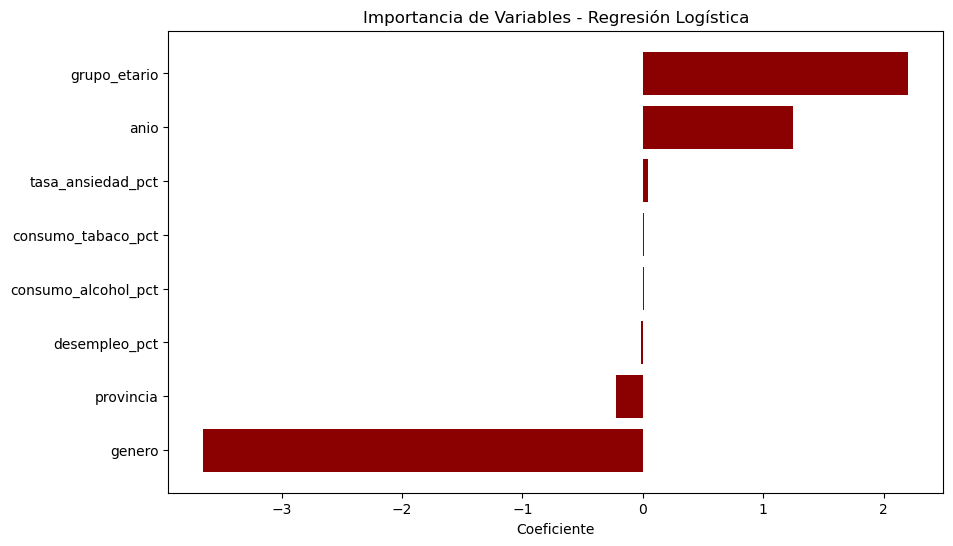

In [29]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_log.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente")

plt.figure(figsize=(10,6))

plt.barh(
    coeficientes["Variable"],
    coeficientes["Coeficiente"],
    color="darkred"
)

plt.title("Importancia de Variables - Regresión Logística")

plt.xlabel("Coeficiente")

plt.show()

### MATRIZ DE CONFUSION

In [22]:
cm_log = confusion_matrix(y_test, pred_log)

df_cm_log = pd.DataFrame(
    cm_log,
    index=["Real Bajo", "Real Alto"],
    columns=["Pred Bajo", "Pred Alto"]
)

df_cm_log

,Pred Bajo,Pred Alto
Real Bajo,69,10
Real Alto,9,80


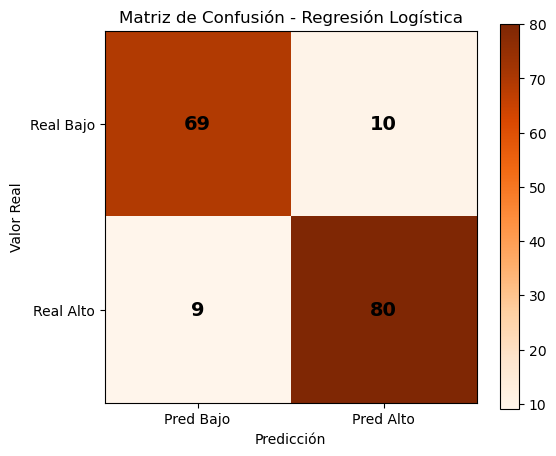

In [30]:
cm_log = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(6,5))

plt.imshow(cm_log, cmap="Oranges")

plt.title("Matriz de Confusión - Regresión Logística")
plt.colorbar()

plt.xticks([0,1], ["Pred Bajo", "Pred Alto"])
plt.yticks([0,1], ["Real Bajo", "Real Alto"])

for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        plt.text(
            j,
            i,
            cm_log[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=14,
            fontweight="bold"
        )

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

## MODELO 2 : ARBOL DE DECISION 
### ENTRENO EL MODELO 

In [23]:
modelo_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### PREDICCIONES

In [24]:
pred_tree = modelo_tree.predict(X_test)

### METRICAS

In [25]:
report_tree = classification_report(
    y_test,
    pred_tree,
    output_dict=True
)

df_report_tree = pd.DataFrame(report_tree).transpose()

df_report_tree

,precision,recall,f1-score,support
0,0.781609,0.860759,0.819277,79.000000
1,0.864198,0.786517,0.823529,89.000000
accuracy,0.821429,0.821429,0.821429,0.821429
macro avg,0.822903,0.823638,0.821403,168.000000
weighted avg,0.825361,0.821429,0.821530,168.000000


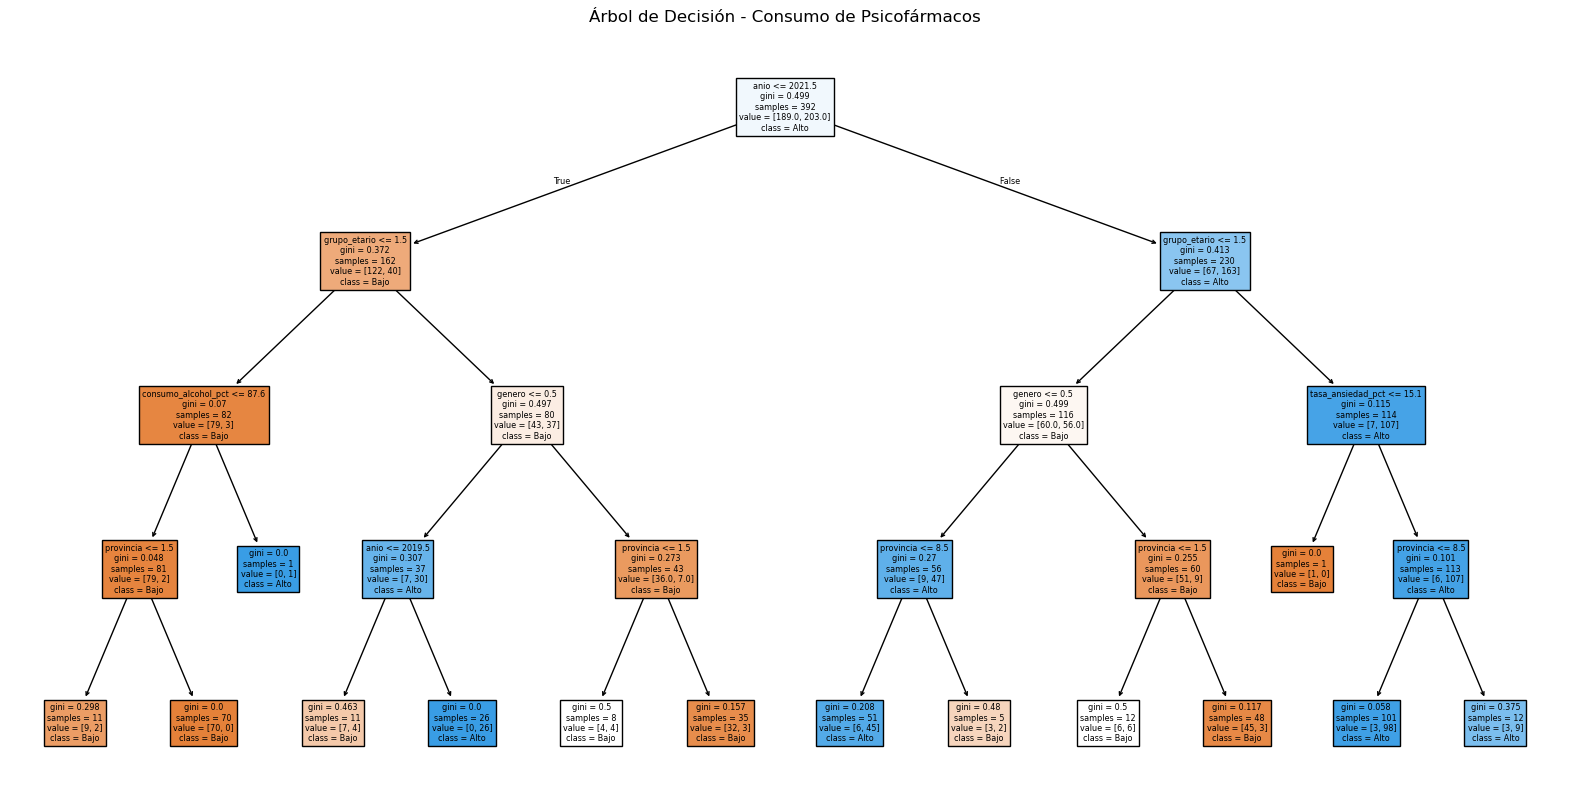

In [28]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    modelo_tree,
    feature_names=X.columns,
    class_names=["Bajo", "Alto"],
    filled=True
)

plt.title("Árbol de Decisión - Consumo de Psicofármacos")

plt.show()

### MATRIZ DE CONFUSION 

In [26]:
cm_tree = confusion_matrix(y_test, pred_tree)

df_cm_tree = pd.DataFrame(
    cm_tree,
    index=["Real Bajo", "Real Alto"],
    columns=["Pred Bajo", "Pred Alto"]
)

df_cm_tree

,Pred Bajo,Pred Alto
Real Bajo,68,11
Real Alto,19,70


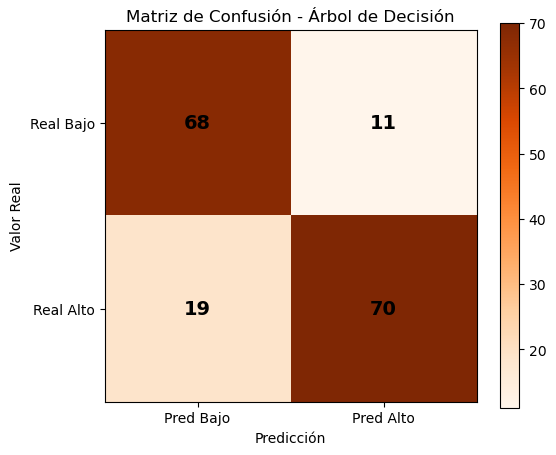

In [31]:
cm_tree = confusion_matrix(y_test, pred_tree)

plt.figure(figsize=(6,5))

plt.imshow(cm_tree, cmap="Oranges")

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.colorbar()

plt.xticks([0,1], ["Pred Bajo", "Pred Alto"])
plt.yticks([0,1], ["Real Bajo", "Real Alto"])


for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        plt.text(
            j,
            i,
            cm_tree[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=14,
            fontweight="bold"
        )

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# CONCLUSION 

### En este trabajo se aplicaron técnicas de Machine Learning para analizar el consumo de psicofármacos en Argentina entre los años 2019 y 2025, utilizando variables sociales y demográficas relacionadas con salud mental, hábitos de consumo y contexto socioeconómico.

### El objetivo principal fue construir modelos capaces de clasificar si un caso correspondía a un consumo alto o bajo de psicofármacos. Para ello se utilizaron dos modelos supervisados: Regresión Logística y Árbol de Decisión.

A partir de las métricas obtenidas, la Regresión Logística fue el modelo que presentó el mejor desempeño general. Alcanzó un accuracy cercano al 89%, además de valores elevados de precisión y recall para la clase de consumo alto. Esto indica que el modelo logró identificar correctamente la mayoría de los casos positivos y cometer una menor cantidad de errores de clasificación, especialmente falsos negativos.

Por otro lado, el Árbol de Decisión obtuvo un rendimiento menor, con un accuracy cercano al 82% y una mayor cantidad de falsos negativos. Sin embargo, este modelo presentó la ventaja de ser más visual e interpretable, permitiendo comprender de manera más sencilla cómo las variables influyen en la toma de decisiones del modelo.

El análisis también permitió observar que variables como la ansiedad, el grupo etario y el consumo de alcohol y tabaco tuvieron una influencia importante en la predicción del consumo de psicofármacos, mostrando la relación existente entre factores sociales, emocionales y hábitos de consumo.

En conclusión, la Regresión Logística resultó ser el modelo más adecuado para este problema debido a su mayor capacidad predictiva y mejor equilibrio entre precisión y recall. Además, este trabajo permitió aplicar conceptos de análisis de datos, evaluación de modelos y aprendizaje automático sobre una problemática social real, demostrando cómo la inteligencia artificial puede utilizarse como herramienta de apoyo para el análisis e interpretación de fenómenos vinculados a la salud mental.